# Problem lokalizacije izvora #
## student: Ivan Tomić ##
## mentor: prof. dr. sc. Luka Grubišić ##
### 1. projektni zadatak ###
### kolegij: Inverzni problemi i strojni vid ###


# Uvod #

U ovom projektnom zadatku razmatra se problem lokalizacije izvora signala formuliran kao inverzni problem.

Cilj je procijeniti nepoznatu lokaciju izvora $x^* \in (0, 1)$ na temelju šumom kontaminiranih mjerenja dobivenih na rubovima intervala.

Promatrani problem je:

$y = F(x)+ \eta$

gdje je:

$x$ nepoznati parametar (lokacija izvora),
$F(x)$ forward model,
$\eta$ Gaussov šum.

Koristi se Bayesov pristup, gdje se rekonstruira posteriorna distribucija:



$\pi(x|y)$ $\propto $ $P(y|x)\pi(x)$      

te se iz nje određuje procjena izvora.

Uvozimo potrebne biblioteke.

In [139]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
np.random.seed(42)

# Definicija forward modela #

Model napona:

$y(x) = \frac{1}{|x - x_i|}$

Mjerenja se uzimaju na:
$x_0 = 0$
$x_1 = 1$

In [140]:
def forward(x):
    y1 = 1 / np.abs(x - 0)
    y2 = 1 / np.abs(x - 1)
    return np.array([y1, y2])

# Generiranje statističkih mjerenja #

Poznata stvarna pozicija izvora:

$x^* = \frac{1}{\pi}$

Dodajemo Gaussov šum:

$\eta$ ~ $\mathcal{N} (0, \sigma^2)$   

In [141]:
x_true = 1 / np.pi
sigma = 0.2

y_true = forward(x_true)

noise = sigma * np.random.randn(2)
y_obs = y_true + noise

print("Ground truth:", x_true)
print("Observed data:", y_obs)

Ground truth: 0.3183098861837907
Observed data: [3.24093548 1.43928935]


# Definicija posteriorne gustoće #

Dana je vjerojatnost

$\mathbb{P}(y|x) \propto \exp (-\frac{1}{2\sigma^2} \sum_{j = 0}^{1} (y_j - \frac{1}{|x - j|})^2)$

Također, promatramo jediničnu funkciju

$\pi(x) = \chi_{(0, 1)} (x) $ 

In [142]:
def posterior(x_grid, y_obs, sigma):
    values = []

    for x in x_grid:
        y_model = forward(x)
        
        misfit = np.sum((y_obs - y_model)**2)

        p = np.exp(-misfit / (2 * sigma**2))
        values.append(p)

    values = np.array(values)

    # normalizacija
    values /= np.trapz(values, x_grid)

    return values

# Vizualizacija posteriora #

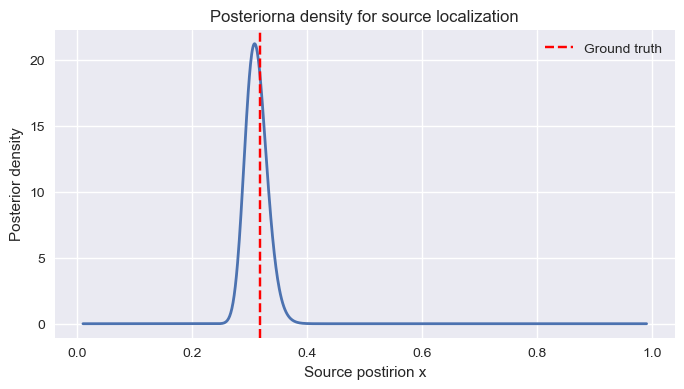

In [143]:
x_grid = np.linspace(0.01, 0.99, 1000)

post = posterior(x_grid, y_obs, sigma)

plt.figure(figsize=(8,4))
plt.plot(x_grid, post, linewidth=2)
plt.axvline(x_true, color='red', linestyle='--', label='Ground truth')

plt.xlabel('Source postirion x')
plt.ylabel('Posterior density')
plt.title('Posteriorna density for source localization')
plt.legend()
plt.grid(True)
plt.show()

# MAP procjena #

Procjenitelj maksimalne aposteriorne vjerojatnosti (MAP procjenitelj) definiramo na sljedeći način:

$x_{MAP} = \arg \max  \pi(x|y)$


In [144]:
x_map = x_grid[np.argmax(post)]

print("MAP estimate:", x_map)
print("Absolute error:", abs(x_map - x_true))

MAP estimate: 0.3082182182182182
Absolute error: 0.010091667965572482


Sada problem maksimizacije možemo zapravo svesti na problem minimizacije na način da logaritmiramo prethodni procjenitelj. Dobivamo:

$\log \pi(x|y) = -\frac{1}{2\sigma^2} \sum_{j = 0}^{1} (y_j - \frac{1}{|x - j|})^2 + C $

Budući da maksimizaciju svodimo na minimizaciju, mijenjamo predznak te dobivamo:

$J(x) = -\log \pi(x|y)= \frac{1}{2\sigma^2} \sum (y_j - \frac{1}{|x - j|})^2$

In [145]:
from scipy.optimize import minimize

def objective(x, y_obs, sigma):
    x = float(x)
    y_model = forward(x)
    return np.sum((y_obs - y_model)**2)/(2*sigma**2)

res = minimize(
    lambda z: objective(z[0], y_obs, sigma),
    x0=[0.5],
    bounds=[(0.01,0.99)]
)

print(res.x)

resolutions = [20, 50, 100, 200, 500, 1000]
estimates = []

for n in resolutions:
    grid = np.linspace(0.01,0.99,n)
    post = posterior(grid, y_obs, sigma)
    x_est = grid[np.argmax(post)]
    estimates.append(x_est)





[0.30842629]


## Graf konvergencije ##

Promotrimo sada graf konvergencije MAP procjenitelja.

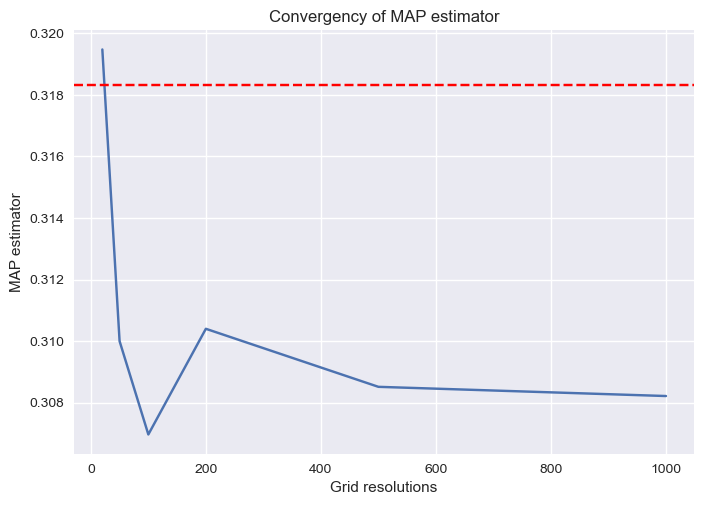

In [146]:
plt.plot(resolutions, estimates)
plt.axhline(x_true, color='r', linestyle='--')
plt.xlabel('Grid resolutions')
plt.ylabel('MAP estimator')
plt.title('Convergency of MAP estimator')
plt.show()

# Empirijska analiza greške (Monte Carlo)

In [147]:
N = 200
errors = []

for i in range(N):

    noise = sigma * np.random.randn(2)

    y_obs = forward(x_true) + noise

    post = posterior(x_grid, y_obs, sigma)

    x_est = x_grid[np.argmax(post)]

    err = abs(x_est - x_true)

    errors.append(err)

errors = np.array(errors)

Pogledajmo sada srednju aps. grešku, standardnu devijaciju i maksimalnu grešku:

In [148]:
print("Srednja apsolutna greška:", np.mean(errors))
print("std:", np.std(errors))
print("maksimalna greška:", np.max(errors))

Srednja apsolutna greška: 0.015131631631631628
std: 0.011713365738132482
maksimalna greška: 0.06446288658898208


Grešku možemo prikazati i histogramom:

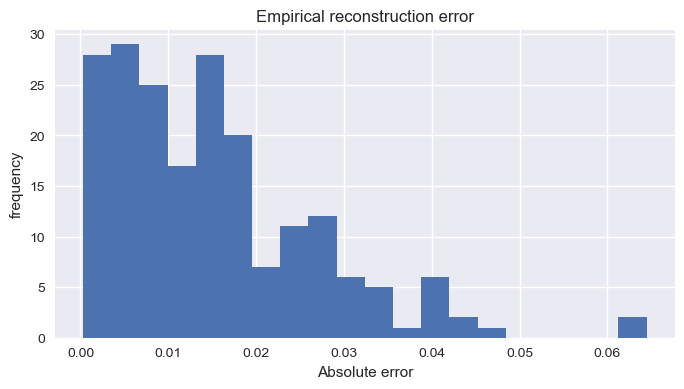

In [149]:
plt.figure(figsize=(8,4))
plt.hist(errors, bins=20)

plt.xlabel('Absolute error')
plt.ylabel('frequency')
plt.title('Empirical reconstruction error')
plt.grid(True)
plt.show()

Sada ćemo usporediti dobivene rezultate s rezultatima dobivenim jednim mjerenjem (koristit ćemo se samo jednom informacijom o istom nepoznatom izvoru, odnosno da imamo samo senzor u nuli umjesto u nuli i jedinici).
Slijedi kod za "jedno mjerenje".

In [150]:
def posterior_single(x_grid, y_obs, sigma):
    values = []

    for x in x_grid:
        y_model = 1 / np.abs(x - 1)

        misfit = (y_obs - y_model)**2

        p = np.exp(-misfit/(2*sigma**2))
        values.append(p)

    values = np.array(values)
    values /= np.trapz(values, x_grid)

    return values


y_single = y_true[1] + sigma*np.random.randn()

post_single = posterior_single(
    x_grid,
    y_single,
    sigma
)

Prikažimo grafom usporedbu:

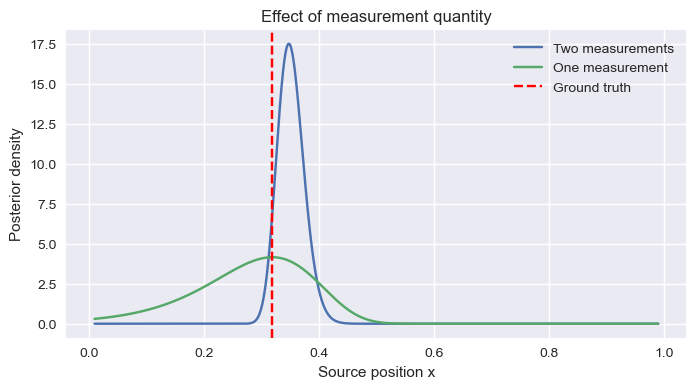

In [151]:
plt.figure(figsize=(8,4))

plt.plot(x_grid, post, label='Two measurements')
plt.plot(x_grid, post_single, label='One measurement')

plt.axvline(
    x_true,
    color='red',
    linestyle='--',
    label='Ground truth'
)

plt.xlabel('Source position x')
plt.ylabel('Posterior density')
plt.title('Effect of measurement quantity')
plt.legend()
plt.grid(True)
plt.show()

# Zaključak #

U ovom radu razmatran je problem lokalizacije izvora signala formuliran kao inverzni problem u Bayesovskom okviru. Promatrani model povezuje nepoznatu poziciju izvora s mjerenjima na rubovima intervala, pri čemu su mjerenja ometana Gaussovim šumom. Time je problem inherentno neodređen i osjetljiv na pogreške u podacima.

Bayesovski pristup omogućuje kombiniranje informacija iz fizikalnog modela i prethodnih pretpostavki o nepoznatom parametru kroz posteriornu distribuciju. Umjesto traženja jedinstvenog rješenja, rekonstrukcija se svodi na analizu vjerojatnosti različitih mogućih lokacija izvora.

Numerički rezultati pokazuju da se posteriorna distribucija koncentrira u blizini stvarne pozicije izvora, dok MAP procjena daje dobru točkastu aproksimaciju rješenja. Stabilnost MAP procjene potvrđena je analizom konvergencije u ovisnosti o rezoluciji diskretizacije, pri čemu se procjena stabilizira prema jedinstvenoj vrijednosti.

Usporedba slučajeva s jednim i dva mjerenja pokazuje da dodatna mjerenja značajno smanjuju širinu posteriorne distribucije, odnosno reduciraju nesigurnost u rekonstrukciji. Time se jasno demonstrira ključna karakteristika inverznih problema – količina i kvaliteta podataka izravno utječu na točnost i stabilnost rješenja.

Zaključno, Bayesovska formulacija ne samo da omogućuje stabilnu rekonstrukciju nepoznatog parametra, nego i pruža prirodan okvir za kvantifikaciju nesigurnosti, što je posebno važno u problemima gdje su podaci ograničeni i šumoviti.